In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = "Arial"

In [2]:
# AICc results
df = pd.DataFrame({
    "Model": ["Null", "Mut", "Filt", "Add", "MutFilt", "FiltAdd", "MultAdd", "Full"],
    "R2":    [0.9511, 0.9733, 0.9627, 0.9776, 0.9758, 0.9852, 0.9809, 0.9856],
    "k":     [4, 5, 5, 5, 6, 6, 6, 7],
    "AICc":  [-87.094, -103.63, -92.933, -109.25, -103.72, -119.46, -111.30, -117.03]
})

df["DeltaAICc"] = df["AICc"] - df["AICc"].min()

# order models by Delta AICc
df = df.sort_values("DeltaAICc").reset_index(drop=True)

# Define which parameters vary in each model
params = ["Additive", "Multiplicative", "External filtering"]

model_flags = {
    "Null":    [0, 0, 0],
    "Add":     [1, 0, 0],
    "Mut":     [0, 1, 0],
    "Filt":    [0, 0, 1],
    "MultAdd": [1, 1, 0],
    "MutFilt": [0, 1, 1],
    "FiltAdd": [1, 0, 1],
    "Full":    [1, 1, 1],
}

flag_matrix = np.array([model_flags[m] for m in df["Model"]]).T

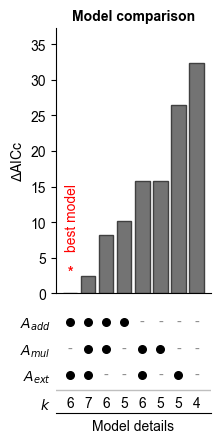

In [3]:
# Plot
fig = plt.figure(figsize=(2, 5))

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[4, 1.7],
    hspace=0.04
)

ax = fig.add_subplot(gs[0])
ax_mat = fig.add_subplot(gs[1], sharex=ax)

x = np.arange(len(df))

# Bar plot
ax.bar(
    x,
    df["DeltaAICc"],
    color="0.45",
    edgecolor="0.25"
)

ax.set_ylabel(r"$\Delta$AICc", fontsize=10)
ax.set_title("Model comparison", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(df["DeltaAICc"]) * 1.15)

# Best model label
best_x = df["DeltaAICc"].idxmin()

ax.text(
    best_x,
    2,
    "*",
    color="red",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    best_x - 0.28,
    6,
    "best model",
    rotation=90,
    color="red",
    fontsize=10,
    va="bottom"
)

ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Model details matrix
k_y = -1.05

ax_mat.set_ylim(-1.45, len(params) - 0.2)

for i, param in enumerate(params):
    y = len(params) - 1 - i
    
    for j in range(len(df)):
        if flag_matrix[i, j] == 1:
            ax_mat.scatter(
                j,
                y,
                s=30,
                color="black"
            )
        else:
            ax_mat.text(
                j,
                y,
                "-",
                ha="center",
                va="center",
                color="0.55",
                fontsize=10
            )

# Divider above k row
ax_mat.axhline(
    -0.55,
    color="0.75",
    lw=1
)

# k row
for j, kval in enumerate(df["k"]):
    ax_mat.text(
        j,
        k_y,
        str(kval),
        ha="center",
        va="center",
        fontsize=10
    )

ax_mat.set_yticks([2, 1, 0, k_y])
ax_mat.set_yticklabels(
    [r"$A_{add}$", r"$A_{mul}$", r"$A_{ext}$", r"$k$"],
    fontsize=10
)

# Remove model names
ax_mat.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False
)

ax_mat.set_xlabel("Model details", fontsize=10)

ax_mat.spines["top"].set_visible(False)
ax_mat.spines["right"].set_visible(False)
ax_mat.spines["left"].set_visible(False)
ax_mat.tick_params(axis="y", length=0)

fig.canvas.draw()

fig.savefig(
    "AIC.pdf",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)

plt.show()